In [129]:
import numpy as np
import pandas as pd
import h5py
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt

In [161]:
file = "H-H1_GWOSC_16KHZ_R1-1185389792-32.hdf5"

In [162]:
with h5py.File("H-H1_GWOSC_16KHZ_R1-1185389792-32.hdf5", "r") as f:
    print("Top-level Keys:", list(f.keys()))
    strain = f["strain"]["Strain"][:]
    duration = f["meta"]["Duration"]
    print(strain[:10])
    #print(duration[:10])
    #print(type(duration[:]))

Top-level Keys: ['meta', 'quality', 'strain']
[-3.77432703e-19 -4.36540253e-19 -4.03297246e-19 -2.93484775e-19
 -1.82002594e-19 -1.05146990e-19 -6.10426472e-20 -7.63951086e-20
 -8.71657684e-20 -1.10474795e-19]


In [163]:
with h5py.File("H-H1_LOSC_4_V1-1126259446-32.hdf5", "r") as f:
    def print_structure(name, obj):
        print(name)
    f.visititems(print_structure)

meta
meta/Description
meta/DescriptionURL
meta/Detector
meta/Duration
meta/GPSstart
meta/Observatory
meta/Type
meta/UTCstart
quality
quality/detail
quality/injections
quality/injections/InjDescriptions
quality/injections/InjShortnames
quality/injections/Injmask
quality/simple
quality/simple/DQDescriptions
quality/simple/DQShortnames
quality/simple/DQmask
strain
strain/Strain


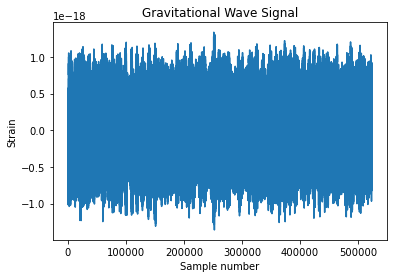

In [164]:
strain = np.nan_to_num(strain)

# Make a simple x-axis (just sample numbers)
x = np.arange(len(strain))

# Plot the signal
plt.plot(x, strain)
plt.xlabel("Sample number")
plt.ylabel("Strain")
plt.title("Gravitational Wave Signal")
plt.show()

In [165]:
with h5py.File(file, "r") as f:
    strain = f["strain"]["Strain"]
    print("shape:", strain.shape)
    print("type:", strain.dtype)
    print("Strain Type:", type(strain))
    print("STRAIN:", type(strain[:]))
    strain = strain[:]

shape: (524288,)
type: float64
Strain Type: <class 'h5py._hl.dataset.Dataset'>
STRAIN: <class 'numpy.ndarray'>


In [166]:
strain = np.nan_to_num(strain)

In [167]:
x = np.arange(len(strain))

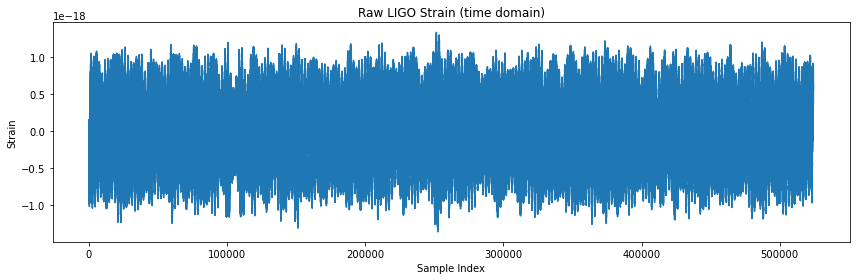

In [168]:
plt.figure(figsize=(12, 4))
plt.plot(x, strain)
plt.xlabel("Sample Index")
plt.ylabel("Strain")
plt.title("Raw LIGO Strain (time domain)")
plt.tight_layout()
plt.show()

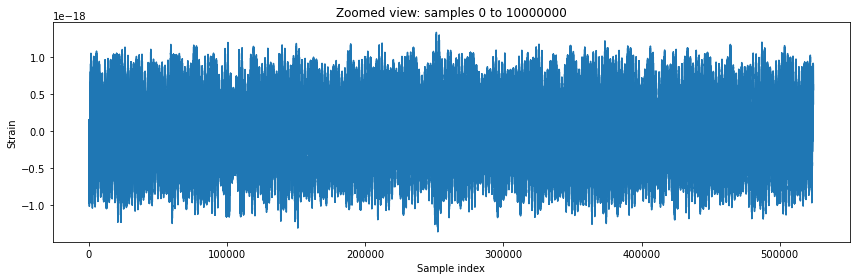

In [169]:
start = 0# change these to move the window
window = 10000000# number of points to show
plt.figure(figsize=(12, 4))
plt.plot(x[start:start+window], strain[start:start+window])
plt.xlabel("Sample index")
plt.ylabel("Strain")
plt.title(f"Zoomed view: samples {start} to {start+window}")
plt.tight_layout()
plt.show()

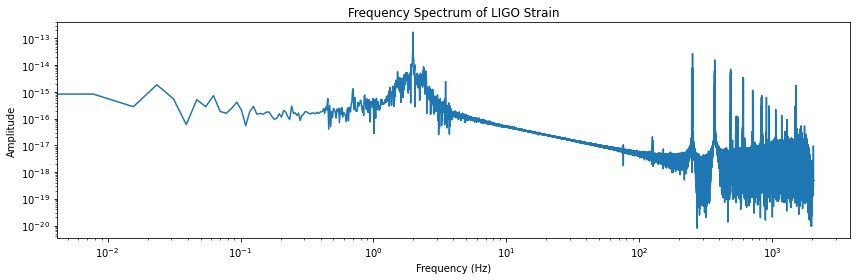

In [170]:
N = len(strain)             # Number of data points
dt = 1 / 4096               # Sampling interval (LIGO sample rate is 4096 Hz)

# 3) FFT calculation
freqs = np.fft.rfftfreq(N, dt)      # Frequency bins
fft_values = np.abs(np.fft.rfft(strain))  # FFT magnitudes

# 4) Plot
plt.figure(figsize=(12, 4))
plt.loglog(freqs, fft_values)
plt.xlabel("Frequency (Hz)")
plt.ylabel("Amplitude")
plt.title("Frequency Spectrum of LIGO Strain")
plt.tight_layout()
plt.show()

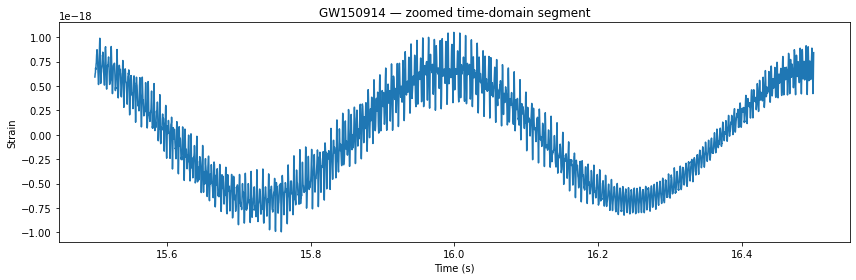

In [171]:
# GW150914 is ~16 s into this 32 s file
t0, t1 = 15.5, 16.5                     # tweak these (seconds)
i0, i1 = int(t0*fs), int(t1*fs)
seg = strain[i0:i1]
t = np.arange(len(seg))/fs + t0

plt.figure(figsize=(12,4))
plt.plot(t, seg)
plt.xlabel("Time (s)"); plt.ylabel("Strain")
plt.title("GW150914 — zoomed time-domain segment")
plt.tight_layout(); plt.show()

In [172]:
n = [1+2j , 3+4j]

In [173]:
np.abs(n)

array([2.23606798, 5.        ])

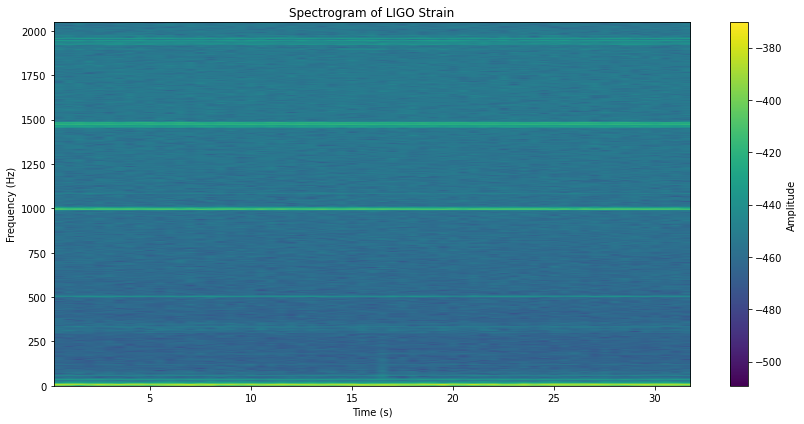

In [182]:
# Spectrogram
plt.figure(figsize=(12, 6))
#plt.specgram(strain, NFFT=4096, Fs=4096, noverlap=2048, cmap='viridis')
plt.specgram(strain + 1e-20, NFFT=4096, Fs=4096, noverlap=2048, cmap='viridis')
plt.xlabel("Time (s)")
plt.ylabel("Frequency (Hz)")
plt.title("Spectrogram of LIGO Strain")
plt.colorbar(label='Amplitude')
plt.tight_layout()
plt.show()

In [183]:
fs = 4096        # samples per second
window_size = fs # 1-second windows

# Split into windows
windows = []
for start in range(0, len(strain), window_size):
    end = start + window_size
    if end <= len(strain):
        windows.append(strain[start:end])

windows = np.array(windows)
print("Number of windows:", windows.shape[0])
print("Samples per window:", windows.shape[1])

Number of windows: 32
Samples per window: 4096


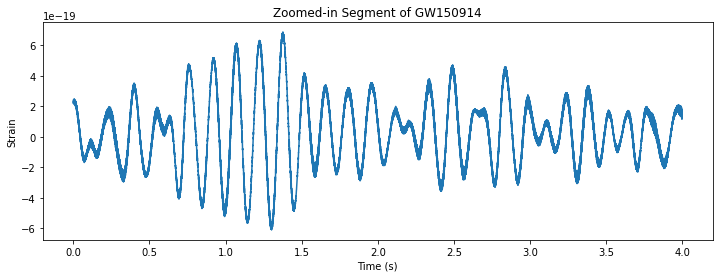

In [184]:
start = 14 * 4096   # start at 14s
end = 18 * 4096     # end at 18s

segment = strain[start:end]

plt.figure(figsize=(12, 4))
plt.plot(np.arange(len(segment)) / 4096, segment)
plt.xlabel("Time (s)")
plt.ylabel("Strain")
plt.title("Zoomed-in Segment of GW150914")
plt.show()

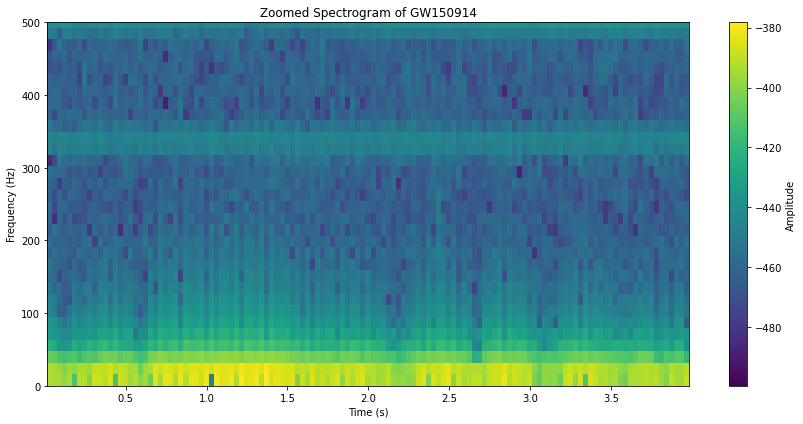

In [185]:
plt.figure(figsize=(12, 6))
plt.specgram(segment, NFFT=256, Fs=4096, noverlap=128, cmap='viridis')
plt.xlabel("Time (s)")
plt.ylabel("Frequency (Hz)")
plt.title("Zoomed Spectrogram of GW150914")
plt.ylim(0, 500)  # focus on 0–300 Hz where chirp lives
plt.colorbar(label="Amplitude")
plt.tight_layout()
plt.show()

In [186]:
# 1) Load + basic clean
fs = 4096  # samples/sec
with h5py.File("H-H1_LOSC_4_V1-1126259446-32.hdf5","r") as f:
    strain = np.nan_to_num(f["strain"]["Strain"][:])

# 2) Band-pass design (Butterworth)
def bandpass(x, fs, lo=30.0, hi=300.0, order=4):
    nyq = 0.5 * fs
    lo_n, hi_n = lo/nyq, hi/nyq
    b, a = butter(order, [lo_n, hi_n], btype="band")
    # filtfilt = zero-phase (no lag), handles edges better than lfilter
    return filtfilt(b, a, x)

strain_bp = bandpass(strain, fs, 30, 300, order=4)

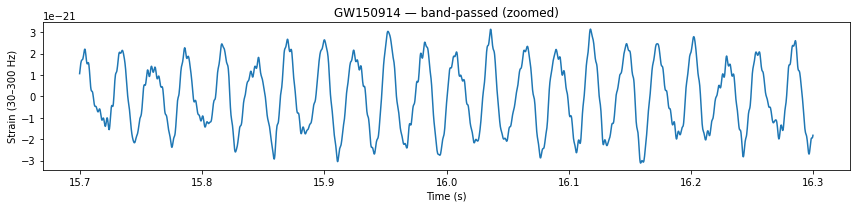

In [187]:
import matplotlib.pyplot as plt
t0, t1 = 15.7, 16.3
i0, i1 = int(t0*fs), int(t1*fs)
t = np.arange(i0, i1)/fs
plt.figure(figsize=(12,3))
plt.plot(t, strain_bp[i0:i1])
plt.xlabel("Time (s)"); plt.ylabel("Strain (30–300 Hz)")
plt.title("GW150914 — band-passed (zoomed)")
plt.tight_layout(); plt.show()

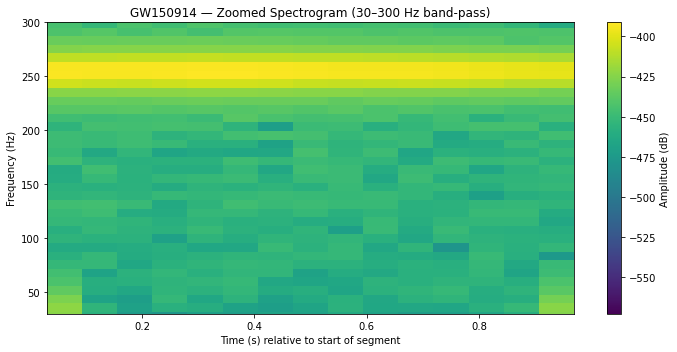

In [188]:
def bandpass(x, fs, lo=30, hi=300, order=4):
    nyq = 0.5*fs
    b,a = butter(order, [lo/nyq, hi/nyq], btype="band")
    return filtfilt(b,a,x)

seg_bp = bandpass(seg, fs, 30, 300)

plt.figure(figsize=(10,5))
Pxx, freqs, bins, im = plt.specgram(seg_bp, NFFT=512, Fs=fs, noverlap=256, cmap='viridis')
plt.ylim(30, 300)
plt.xlabel("Time (s) relative to start of segment")
plt.ylabel("Frequency (Hz)")
plt.title("GW150914 — Zoomed Spectrogram (30–300 Hz band-pass)")
plt.colorbar(label="Amplitude (dB)")
plt.tight_layout(); plt.show()